# Sentinel-5P Data Access and Initial Inspection

This notebook establishes a connection to the Copernicus Data
Space Ecosystem and performs a small-scale test download of
Sentinel-5P methane observations over the Po Valley.

A limited spatial and temporal extent is used first to inspect
the structure, coverage, and basic statistics of the data before
running the full multiyear acquisition pipeline.

## 1. Setup and Copernicus connection

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from po_valley_methane_forecasting.paths import find_project_root
from po_valley_methane_forecasting.data_access import (
    connect_to_copernicus, build_ch4_cube, download_datacube_to_netcdf, load_xarray_dataset
)

In [2]:
import openeo
print("openEO version:", openeo.client_version())

openEO version: 0.50.0


In [3]:
project_root = find_project_root()

raw_data_dir = project_root / "data" / "raw"
raw_data_dir.mkdir(parents=True, exist_ok=True)

output_path = raw_data_dir / "sentinel5p_ch4_test_june_2024.nc"

print("Project root:", project_root)
print("Output file:", output_path)

Project root: c:\Users\Pietro\OneDrive\Desktop\po_valley_methane_forecasting
Output file: c:\Users\Pietro\OneDrive\Desktop\po_valley_methane_forecasting\data\raw\sentinel5p_ch4_test_june_2024.nc


In [4]:
connection=connect_to_copernicus()

Authenticated using refresh token.


In [5]:
collection = connection.describe_collection("SENTINEL_5P_L2")
bands = collection["cube:dimensions"]["bands"]["values"]
assert "CH4" in bands
print("CH4 band available.")

CH4 band available.


## 2. Small test data cube

In [6]:
test_spatial_extent = {
    "west": 8.5,
    "south": 44.8,
    "east": 10.5,
    "north": 46.0,
    "crs": "EPSG:4326",
}

test_temporal_extent = ("2024-06-01", "2024-07-01")

ch4_cube = build_ch4_cube(connection, test_spatial_extent, test_temporal_extent)

ch4_cube.print_json()

{
  "process_graph": {
    "loadcollection1": {
      "process_id": "load_collection",
      "arguments": {
        "bands": [
          "CH4"
        ],
        "id": "SENTINEL_5P_L2",
        "spatial_extent": {
          "west": 8.5,
          "south": 44.8,
          "east": 10.5,
          "north": 46.0,
          "crs": "EPSG:4326"
        },
        "temporal_extent": [
          "2024-06-01",
          "2024-07-01"
        ]
      },
      "result": true
    }
  }
}


## 3. NetCDF download and xarray inspection

In [7]:
download_datacube_to_netcdf(ch4_cube, output_path)

File already available: sentinel5p_ch4_test_june_2024.nc — skipping download.


In [8]:
ds = load_xarray_dataset(output_path)

In [9]:
print("Dimensions:")
print(ds.sizes)

print("\nCoordinates:")
print(list(ds.coords))

print("\nData variables:")
print(list(ds.data_vars))

Dimensions:
Frozen({'t': 26, 'x': 37, 'y': 35})

Coordinates:
['t', 'x', 'y']

Data variables:
['crs', 'CH4']


In [10]:
assert "CH4" in ds.data_vars, (
    f"CH4 not found. Available variables: {list(ds.data_vars)}"
)

ch4 = ds["CH4"]

In [11]:
print("CH4 dimensions:", ch4.dims)
print("CH4 shape:", ch4.shape)
print("CH4 attributes:", ch4.attrs)

print("Valid observations:", ch4.count().values)
print("Minimum:", ch4.min(skipna=True).values)
print("Maximum:", ch4.max(skipna=True).values)
print("Mean:", ch4.mean(skipna=True).values)

CH4 dimensions: ('t', 'y', 'x')
CH4 shape: (26, 35, 37)
CH4 attributes: {'long_name': 'CH4', 'units': '', 'grid_mapping': 'crs'}
Valid observations: 2328
Minimum: 1769.3798
Maximum: 1956.149
Mean: 1903.0693


In [12]:
time_dim = next(
    (dim for dim in ["t", "time"] if dim in ch4.dims),
    None,
)

print("Time dimension:", time_dim)

Time dimension: t


## 4. Initial visualization

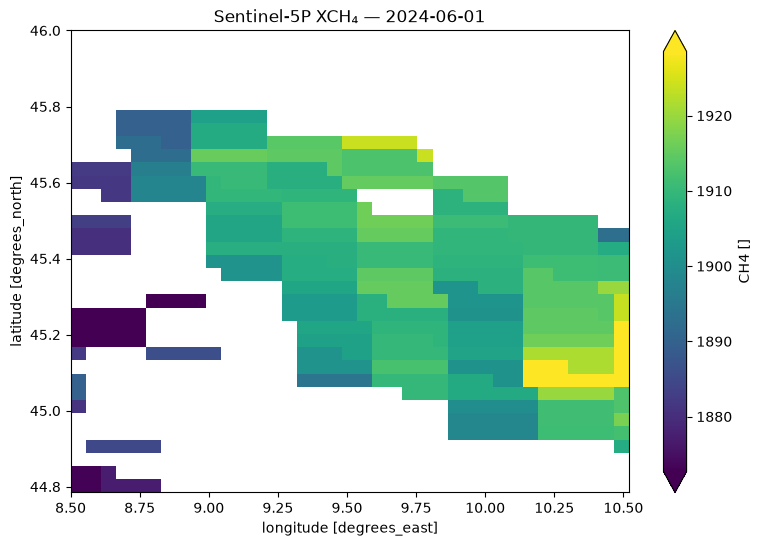

In [13]:
if time_dim is not None:
    first_time = pd.to_datetime(ch4[time_dim].values[0])

    first_observation = ch4.isel({time_dim: 0})

    first_observation.plot(
        figsize=(9, 6),
        robust=True,
    )

    plt.title(f"Sentinel-5P XCH₄ — {first_time:%Y-%m-%d}")
    plt.show()
else:
    print("No temporal dimension found.")

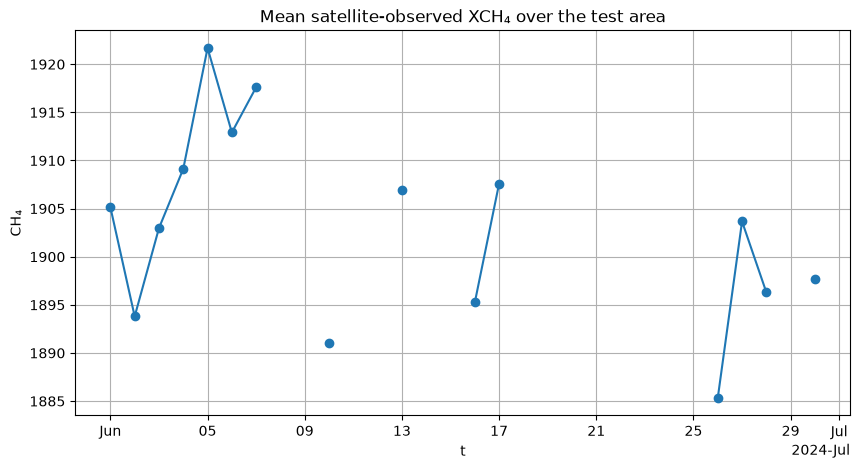

In [14]:
if time_dim is not None:
    spatial_dims = [
        dim for dim in ch4.dims
        if dim != time_dim
    ]

    regional_mean = ch4.mean(
        dim=spatial_dims,
        skipna=True,
    )

    regional_mean.plot(
        marker="o",
        figsize=(10, 5),
    )

    plt.title("Mean satellite-observed XCH₄ over the test area")
    plt.ylabel("CH₄")
    plt.grid()
    plt.show()

## Conclusions

The test confirms that Sentinel-5P CH4 data can be retrieved
successfully and represented as a three-dimensional
time × latitude × longitude data cube. Missing observations are
present and will require explicit coverage analysis before
constructing the forecasting dataset.